In [ ]:
from google.colab import drive
drive.mount("/content/drive")
import sys
!{sys.executable} -m pip install nltk torch torchvision tqdm -q

Mounted at /content/drive


In [ ]:
import pickle, json
from pathlib import Path

# ── Point this at wherever you put the artefacts folder in your Drive ──
ARTEFACTS_DIR = Path("/content/drive/MyDrive/artefacts/artefacts")
IMAGE_DIR      = Path("/content/drive/MyDrive/val")

# ── Load vocabulary ────────────────────────────────────────────────────
with open(ARTEFACTS_DIR / "vocab.pkl", "rb") as f:
    vocab_data = pickle.load(f)

# ── Load splits ────────────────────────────────────────────────────────
with open(ARTEFACTS_DIR / "splits.json") as f:
    splits = json.load(f)

train_ids = set(int(x) for x in splits["train"])
val_ids   = set(int(x) for x in splits["val"])
test_ids  = set(int(x) for x in splits["test"])

# ── Load id → tokens mapping ───────────────────────────────────────────
with open(ARTEFACTS_DIR / "id_to_tokens.json") as f:
    id_to_tokens_raw = json.load(f)
id_to_tokens = {int(k): v for k, v in id_to_tokens_raw.items()}

# ── Load processed captions dataframe ─────────────────────────────────
import pandas as pd
df = pd.read_csv(ARTEFACTS_DIR / "captions_processed.csv")
# tokens column was saved as string — eval it back to list
import ast
df["tokens"] = df["tokens"].apply(ast.literal_eval)

# ── Load id → filename mapping ─────────────────────────────────────────
id_to_filename = dict(zip(df["image_id"], df["file_name"]))
id_to_filename = {k: v for k, v in
                  {iid: df[df["image_id"]==iid]["file_name"].iloc[0]
                   for iid in df["image_id"].unique()}.items()}

print(f"Vocab size : {vocab_data['vocab_size']}")
print(f"Train      : {len(train_ids)} images")
print(f"Val        : {len(val_ids)} images")
print(f"Test       : {len(test_ids)} images")
print(f"PAD={vocab_data['pad_idx']}  UNK={vocab_data['unk_idx']}  "
      f"SOS={vocab_data['sos_idx']}  EOS={vocab_data['eos_idx']}")

Vocab size : 3274
Train      : 5425 images
Val        : 1162 images
Test       : 1163 images
PAD=0  UNK=3  SOS=1  EOS=2


In [ ]:
from typing import Dict, List

class Vocabulary:
    PAD_TOKEN   = "<PAD>";  PAD_IDX   = 0
    START_TOKEN = "<START>"; START_IDX = 1
    END_TOKEN   = "<END>";   END_IDX   = 2
    UNK_TOKEN   = "<UNK>";   UNK_IDX   = 3

    def __init__(self, vocab_data: dict):
        self.word2idx: Dict[str, int] = vocab_data["stoi"]
        self.idx2word: Dict[int, str] = {i: w for i, w in enumerate(vocab_data["itos"])}
        self.vocab_size = vocab_data["vocab_size"]

    def encode(self, tokens: List[str]) -> List[int]:
        return ([self.START_IDX]
                + [self.word2idx.get(t, self.UNK_IDX) for t in tokens]
                + [self.END_IDX])

    def decode(self, indices: List[int], skip_special: bool = True) -> str:
        special = {self.PAD_IDX, self.START_IDX, self.END_IDX}
        words = []
        for idx in indices:
            if idx == self.END_IDX:
                break
            if skip_special and idx in special:
                continue
            words.append(self.idx2word.get(idx, self.UNK_TOKEN))
        return " ".join(words)

    def __len__(self):
        return self.vocab_size

vocab = Vocabulary(vocab_data)
print(f"Vocabulary loaded: {len(vocab)} tokens")

# Quick sanity check
test_tokens = ["a", "person", "holding", "a", "bottle"]
print(f"Encode test : {vocab.encode(test_tokens)}")
print(f"Decode test : {vocab.decode(vocab.encode(test_tokens))}")

Vocabulary loaded: 3274 tokens
Encode test : [1, 55, 2109, 1369, 55, 347, 2]
Decode test : a person holding a bottle


In [ ]:
import os
import random
import numpy as np
from pathlib import Path
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
from tqdm import tqdm

import nltk
nltk.download("punkt", quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# ── Reproducibility ────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ─────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device        :", DEVICE)
print("Torch version :", torch.__version__)
if torch.cuda.is_available():
    print("GPU           :", torch.cuda.get_device_name(0))
    print("VRAM          :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

Device        : cuda
Torch version : 2.10.0+cu128
GPU           : NVIDIA A100-SXM4-80GB
VRAM          : 85.1 GB


In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────
IMAGE_DIR = Path("/content/drive/MyDrive/val")

# ── Model hyperparameters ───────────────────────────────────────────────
EMBED_DIM   = 256      # word embedding dimension
HIDDEN_DIM  = 512      # GRU hidden state dimension
VOCAB_SIZE  = len(vocab)  # 3274
NUM_LAYERS  = 1        # single-layer GRU
DROPOUT     = 0.3      # encoder projection dropout
OUT_DROPOUT = 0.5      # output head dropout

# ── Training hyperparameters ────────────────────────────────────────────
BATCH_SIZE      = 64       # safe on 80GB A100
NUM_EPOCHS      = 20
DECODER_LR      = 3e-4     # decoder trains from scratch — higher lr
ENCODER_LR      = 1e-5     # unfrozen encoder layers — very small lr
LR_PATIENCE     = 2        # epochs before ReduceLROnPlateau fires
EARLY_STOP_PAT  = 5        # epochs without val loss improvement before stopping
GRAD_CLIP       = 5.0      # gradient clipping max norm
MAX_CAPTION_LEN = 50       # matches Phase 1

# ── Decoding ────────────────────────────────────────────────────────────
MAX_GEN_LEN = 52           # MAX_CAPTION_LEN + 2 for <START>/<END>

print("Config set.")
print(f"  Vocab size  : {VOCAB_SIZE}")
print(f"  Embed dim   : {EMBED_DIM}")
print(f"  Hidden dim  : {HIDDEN_DIM}")
print(f"  Batch size  : {BATCH_SIZE}")
print(f"  Decoder lr  : {DECODER_LR}")
print(f"  Encoder lr  : {ENCODER_LR}")

Config set.
  Vocab size  : 3274
  Embed dim   : 256
  Hidden dim  : 512
  Batch size  : 64
  Decoder lr  : 0.0003
  Encoder lr  : 1e-05


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # slight augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms defined.")

Transforms defined.


In [ ]:
class VizWizDataset(Dataset):
    """
    VizWiz captioning dataset.

    Training mode : returns (image, caption_tensor, length)
                    one randomly sampled caption per image.
    Eval mode     : returns (image, all_5_captions, lengths)
                    all 5 reference captions for BLEU evaluation.
    """

    def __init__(
        self,
        image_ids: set,
        id_to_filename: Dict[int, str],
        id_to_tokens: Dict[int, List[List[str]]],
        vocab: Vocabulary,
        image_dir: Path,
        transform: transforms.Compose,
        training: bool = True,
    ) -> None:
        self.vocab      = vocab
        self.image_dir  = image_dir
        self.transform  = transform
        self.training   = training
        self.samples    = []

        missing = 0
        for iid in image_ids:
            fname = id_to_filename.get(iid)
            if fname is None:
                missing += 1
                continue
            path = image_dir / fname
            if not path.exists():
                missing += 1
                continue
            self.samples.append((iid, fname, id_to_tokens[iid]))

        if missing:
            print(f"  [Warning] {missing} images skipped (not found on disk).")
        print(f"  Dataset ({'train' if training else 'eval'}): "
              f"{len(self.samples)} images loaded.")

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        iid, fname, token_lists = self.samples[idx]

        # Load and transform image
        image = Image.open(self.image_dir / fname).convert("RGB")
        image = self.transform(image)

        if self.training:
            # Randomly sample one of the 5 captions per iteration
            tokens  = random.choice(token_lists)
            encoded = self.vocab.encode(tokens)
            caption = torch.tensor(encoded, dtype=torch.long)
            return image, caption, torch.tensor(len(encoded), dtype=torch.long)
        else:
            # Return all 5 captions for multi-reference BLEU
            all_encoded = [
                torch.tensor(self.vocab.encode(toks), dtype=torch.long)
                for toks in token_lists
            ]
            lengths = torch.tensor([len(e) for e in all_encoded], dtype=torch.long)
            return image, all_encoded, lengths

print("VizWizDataset class defined.")

VizWizDataset class defined.


In [ ]:
def collate_train(batch):
    """
    Returns
    -------
    images   : FloatTensor (B, 3, 224, 224)
    captions : LongTensor  (B, T_max) — padded with PAD_IDX
    lengths  : LongTensor  (B,)
    """
    images, captions, lengths = zip(*batch)
    images   = torch.stack(images, dim=0)
    captions = pad_sequence(captions, batch_first=True,
                            padding_value=Vocabulary.PAD_IDX)
    lengths  = torch.stack(lengths, dim=0)
    return images, captions, lengths


def collate_eval(batch):
    """
    Returns
    -------
    images       : FloatTensor (B, 3, 224, 224)
    all_captions : List[List[LongTensor]] — (B x 5 variable-length tensors)
    all_lengths  : LongTensor (B, 5)
    """
    images, all_captions, all_lengths = zip(*batch)
    images      = torch.stack(images, dim=0)
    all_lengths = torch.stack(all_lengths, dim=0)
    return images, list(all_captions), all_lengths

print("Collate functions defined.")

Collate functions defined.


In [ ]:
train_dataset = VizWizDataset(
    image_ids      = train_ids,
    id_to_filename = id_to_filename,
    id_to_tokens   = id_to_tokens,
    vocab          = vocab,
    image_dir      = IMAGE_DIR,
    transform      = train_transform,
    training       = True,
)

val_dataset = VizWizDataset(
    image_ids      = val_ids,
    id_to_filename = id_to_filename,
    id_to_tokens   = id_to_tokens,
    vocab          = vocab,
    image_dir      = IMAGE_DIR,
    transform      = eval_transform,
    training       = False,
)

test_dataset = VizWizDataset(
    image_ids      = test_ids,
    id_to_filename = id_to_filename,
    id_to_tokens   = id_to_tokens,
    vocab          = vocab,
    image_dir      = IMAGE_DIR,
    transform      = eval_transform,
    training       = False,
)

# ── DataLoaders ────────────────────────────────────────────────────────
# num_workers=4 is safe on Colab A100 with High-RAM enabled
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True, collate_fn=collate_train,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True, collate_fn=collate_eval,
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True, collate_fn=collate_eval,
)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

  Dataset (train): 5425 images loaded.
  Dataset (eval): 1162 images loaded.
  Dataset (eval): 1163 images loaded.

Train batches : 84
Val batches   : 19
Test batches  : 19


In [ ]:
class EncoderMobileNet(nn.Module):
    """
    MobileNetV2 image encoder.

    Architecture:
        - Pretrained MobileNetV2 backbone (ImageNet weights)
        - Classifier head removed — we use the 1280-d pooled feature vector
        - All layers frozen except the last inverted residual block (features[17])
        - Linear projection: 1280 → HIDDEN_DIM with ReLU + Dropout
        - Projected vector used to initialise the GRU hidden state

    Why MobileNetV2:
        - Lightweight and fast — good baseline encoder
        - Depthwise separable convolutions reduce compute vs standard CNNs
        - 1280-d output from global average pooling is rich enough for captioning
    """

    def __init__(self, hidden_dim: int, dropout: float = 0.3) -> None:
        super().__init__()

        # Load pretrained MobileNetV2
        base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

        # Remove the classifier head — keep only the feature extractor
        self.backbone = base.features   # output: (B, 1280, 7, 7)
        self.pool     = nn.AdaptiveAvgPool2d((1, 1))  # → (B, 1280, 1, 1)

        # Freeze all backbone layers first
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze only the last inverted residual block (features[17])
        # This allows domain adaptation without destroying pretrained weights
        for param in self.backbone[17].parameters():
            param.requires_grad = True

        # Project 1280-d encoder output → hidden_dim for GRU initialisation
        self.projection = nn.Sequential(
            nn.Linear(1280, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        images : FloatTensor (B, 3, 224, 224)

        Returns
        -------
        features : FloatTensor (B, hidden_dim)
            Projected image features — used to initialise GRU hidden state.
        """
        features = self.backbone(images)       # (B, 1280, 7, 7)
        features = self.pool(features)         # (B, 1280, 1, 1)
        features = features.flatten(1)         # (B, 1280)
        features = self.projection(features)   # (B, hidden_dim)
        return features


# ── Quick shape check ──────────────────────────────────────────────────
_enc = EncoderMobileNet(hidden_dim=HIDDEN_DIM).to(DEVICE)
_dummy = torch.zeros(2, 3, 224, 224).to(DEVICE)
_out   = _enc(_dummy)
print(f"Encoder output shape : {_out.shape}")  # expect (2, 512)

# Count trainable vs frozen parameters
total     = sum(p.numel() for p in _enc.parameters())
trainable = sum(p.numel() for p in _enc.parameters() if p.requires_grad)
print(f"Total params         : {total:,}")
print(f"Trainable params     : {trainable:,}  "
      f"({trainable/total*100:.1f}% of encoder)")
del _enc, _dummy, _out

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 165MB/s]


Encoder output shape : torch.Size([2, 512])
Total params         : 2,879,744
Trainable params     : 1,129,792  (39.2% of encoder)


In [ ]:
class DecoderGRU(nn.Module):
    """
    Single-layer GRU caption decoder.

    Architecture:
        - Embedding layer: vocab_size → embed_dim (trained from scratch)
        - GRU: input=embed_dim, hidden=hidden_dim, num_layers=1
        - Output head: Linear(hidden_dim → vocab_size) + Dropout
        - Image features injected as the initial GRU hidden state (h_0)

    Why trained-from-scratch embeddings:
        VizWiz captions are short, telegraphic, object-focused descriptions
        from blind users — very different from GloVe's Wikipedia/news corpus.
        With 27,125 training captions and vocab_size=3274, there is sufficient
        signal to learn a domain-appropriate embedding space from scratch.

    Why single-layer GRU over LSTM:
        - GRU has fewer parameters (no cell state) — less risk of overfitting
          on a relatively small dataset
        - Faster to train — important for iterating quickly
        - Performance difference vs LSTM is minimal at this scale
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_layers: int = 1,
        dropout: float  = 0.5,
    ) -> None:
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Word embedding layer
        self.embedding = nn.Embedding(
            num_embeddings = vocab_size,
            embedding_dim  = embed_dim,
            padding_idx    = Vocabulary.PAD_IDX,  # PAD tokens don't contribute gradients
        )

        # GRU — processes one token at a time
        self.gru = nn.GRU(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
        )

        # Output projection: hidden state → vocab logits
        self.dropout    = nn.Dropout(dropout)
        self.output_head = nn.Linear(hidden_dim, vocab_size)

    def forward(
        self,
        captions: torch.Tensor,
        hidden: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Teacher-forcing forward pass (training).

        Parameters
        ----------
        captions : LongTensor (B, T)
            Token indices including <START>, excluding final <END>.
        hidden   : FloatTensor (num_layers, B, hidden_dim)
            Initial hidden state from encoder.

        Returns
        -------
        logits : FloatTensor (B, T, vocab_size)
        hidden : FloatTensor (num_layers, B, hidden_dim)
        """
        embeddings = self.embedding(captions)          # (B, T, embed_dim)
        outputs, hidden = self.gru(embeddings, hidden) # (B, T, hidden_dim)
        logits = self.output_head(self.dropout(outputs)) # (B, T, vocab_size)
        return logits, hidden

    def init_hidden(self, encoder_features: torch.Tensor) -> torch.Tensor:
        """
        Reshape encoder output to GRU hidden state shape.

        Parameters
        ----------
        encoder_features : FloatTensor (B, hidden_dim)

        Returns
        -------
        hidden : FloatTensor (num_layers, B, hidden_dim)
        """
        # Unsqueeze to add num_layers dimension
        return encoder_features.unsqueeze(0).repeat(self.num_layers, 1, 1)

    def greedy_decode(
        self,
        encoder_features: torch.Tensor,
        max_len: int = 52,
    ) -> List[List[int]]:
        """
        Greedy decoding — argmax at each timestep.

        Parameters
        ----------
        encoder_features : FloatTensor (B, hidden_dim)
        max_len          : int

        Returns
        -------
        List of token index lists, one per image in batch.
        """
        B = encoder_features.size(0)
        hidden = self.init_hidden(encoder_features)  # (1, B, hidden_dim)

        # Start every sequence with <START>
        current_token = torch.full(
            (B, 1), Vocabulary.START_IDX,
            dtype=torch.long, device=encoder_features.device
        )

        sequences  = [[] for _ in range(B)]
        finished   = [False] * B

        for _ in range(max_len):
            embeddings = self.embedding(current_token)     # (B, 1, embed_dim)
            output, hidden = self.gru(embeddings, hidden)  # (B, 1, hidden_dim)
            logits = self.output_head(self.dropout(output.squeeze(1)))  # (B, vocab_size)
            predicted = logits.argmax(dim=-1)              # (B,)

            for i in range(B):
                if not finished[i]:
                    token = predicted[i].item()
                    if token == Vocabulary.END_IDX:
                        finished[i] = True
                    else:
                        sequences[i].append(token)

            if all(finished):
                break

            current_token = predicted.unsqueeze(1)  # (B, 1)

        return sequences


# ── Quick shape check ──────────────────────────────────────────────────
_dec  = DecoderGRU(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM).to(DEVICE)
_feat = torch.zeros(2, HIDDEN_DIM).to(DEVICE)
_caps = torch.zeros(2, 10, dtype=torch.long).to(DEVICE)
_hid  = _dec.init_hidden(_feat)
_log, _hid2 = _dec(_caps, _hid)
print(f"Decoder logits shape : {_log.shape}")   # expect (2, 10, 3274)
print(f"Hidden state shape   : {_hid2.shape}")  # expect (1, 2, 512)

total = sum(p.numel() for p in _dec.parameters())
print(f"Decoder params       : {total:,}")
del _dec, _feat, _caps, _hid, _log, _hid2

Decoder logits shape : torch.Size([2, 10, 3274])
Hidden state shape   : torch.Size([1, 2, 512])
Decoder params       : 3,700,426


In [ ]:
class ImageCaptioningModel(nn.Module):
    """
    Full image captioning model: Encoder + Decoder.

    Combines EncoderMobileNet and DecoderGRU into a single
    trainable module with a clean forward pass for training
    and a decode method for inference.
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim:  int,
        hidden_dim: int,
        num_layers: int = 1,
        enc_dropout: float = 0.3,
        dec_dropout: float = 0.5,
    ) -> None:
        super().__init__()
        self.encoder = EncoderMobileNet(hidden_dim, enc_dropout)
        self.decoder = DecoderGRU(vocab_size, embed_dim,
                                  hidden_dim, num_layers, dec_dropout)

    def forward(
        self,
        images:   torch.Tensor,
        captions: torch.Tensor,
    ) -> torch.Tensor:
        """
        Teacher-forcing forward pass for training.

        Parameters
        ----------
        images   : FloatTensor (B, 3, 224, 224)
        captions : LongTensor  (B, T)  — includes <START>, excludes last <END>

        Returns
        -------
        logits : FloatTensor (B, T, vocab_size)
        """
        features = self.encoder(images)                   # (B, hidden_dim)
        hidden   = self.decoder.init_hidden(features)     # (1, B, hidden_dim)
        logits, _ = self.decoder(captions, hidden)        # (B, T, vocab_size)
        return logits

    def decode_greedy(
        self,
        images:  torch.Tensor,
        max_len: int = 52,
    ) -> List[List[int]]:
        """Greedy decoding for inference."""
        features = self.encoder(images)
        return self.decoder.greedy_decode(features, max_len)


# ── Instantiate and summarise ──────────────────────────────────────────
model = ImageCaptioningModel(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_layers  = NUM_LAYERS,
    enc_dropout = DROPOUT,
    dec_dropout = OUT_DROPOUT,
).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("=" * 45)
print("  Model 1 — MobileNetV2 + GRU")
print("=" * 45)
print(f"  Total params     : {total:,}")
print(f"  Trainable params : {trainable:,}")
print(f"  Frozen params    : {total - trainable:,}")
print("=" * 45)

  Model 1 — MobileNetV2 + GRU
  Total params     : 6,580,170
  Trainable params : 4,830,218
  Frozen params    : 1,749,952


In [ ]:
# ── Loss ───────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(ignore_index=Vocabulary.PAD_IDX)

# ── Differential learning rates ────────────────────────────────────────
optimizer = optim.Adam([
    {"params": model.encoder.backbone[17].parameters(), "lr": ENCODER_LR},
    {"params": model.encoder.projection.parameters(),   "lr": DECODER_LR},
    {"params": model.decoder.parameters(),              "lr": DECODER_LR},
], lr=DECODER_LR)

# ── LR scheduler ───────────────────────────────────────────────────────
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5,
    patience=LR_PATIENCE,             # verbose removed — deprecated in PyTorch 2.x
)

print("Loss      : CrossEntropyLoss (ignore_index=PAD)")
print("Optimiser : Adam with differential learning rates")
print(f"  Encoder unfrozen lr : {ENCODER_LR}")
print(f"  Decoder lr          : {DECODER_LR}")
print("Scheduler : ReduceLROnPlateau (factor=0.5, patience=2)")

Loss      : CrossEntropyLoss (ignore_index=PAD)
Optimiser : Adam with differential learning rates
  Encoder unfrozen lr : 1e-05
  Decoder lr          : 0.0003
Scheduler : ReduceLROnPlateau (factor=0.5, patience=2)


In [ ]:
def evaluate_bleu(model: nn.Module, loader: DataLoader) -> Dict[str, float]:
    """
    Compute corpus-level BLEU-1/2/3/4 on an eval dataloader.

    Each image has 5 reference captions. We generate one hypothesis
    per image using greedy decoding and score against all 5 references.

    Uses NLTK SmoothingFunction method1 to handle zero n-gram counts
    in short or imperfect captions — standard practice for image captioning.

    Returns
    -------
    dict with keys: bleu1, bleu2, bleu3, bleu4
    """
    model.eval()
    smoother    = SmoothingFunction().method1
    hypotheses  = []   # list of token lists
    references  = []   # list of list-of-token-lists (5 refs per image)

    with torch.no_grad():
        for images, all_captions, _ in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(DEVICE)

            # Generate captions — greedy decode returns List[List[int]]
            preds = model.decode_greedy(images, max_len=MAX_GEN_LEN)

            # Build references for each image in the batch
            for i, pred in enumerate(preds):
                hypotheses.append(pred)

                # Decode all 5 reference captions to token lists (skip special tokens)
                refs = []
                for cap_tensor in all_captions[i]:
                    ref_tokens = [
                        idx.item() for idx in cap_tensor
                        if idx.item() not in {
                            Vocabulary.PAD_IDX,
                            Vocabulary.START_IDX,
                            Vocabulary.END_IDX,
                        }
                    ]
                    refs.append(ref_tokens)
                references.append(refs)

    # Corpus-level BLEU (not average of sentence-level scores)
    bleu1 = corpus_bleu(references, hypotheses,
                        weights=(1, 0, 0, 0), smoothing_function=smoother)
    bleu2 = corpus_bleu(references, hypotheses,
                        weights=(0.5, 0.5, 0, 0), smoothing_function=smoother)
    bleu3 = corpus_bleu(references, hypotheses,
                        weights=(0.333, 0.333, 0.333, 0), smoothing_function=smoother)
    bleu4 = corpus_bleu(references, hypotheses,
                        weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother)

    return {
        "bleu1": round(bleu1 * 100, 2),
        "bleu2": round(bleu2 * 100, 2),
        "bleu3": round(bleu3 * 100, 2),
        "bleu4": round(bleu4 * 100, 2),
    }

print("evaluate_bleu() defined.")

evaluate_bleu() defined.


In [ ]:
def train_one_epoch(
    model:     nn.Module,
    loader:    DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
) -> float:
    """
    Run one full training epoch.

    Uses teacher forcing — ground truth tokens fed as decoder input
    at each timestep rather than the model's own predictions.
    This stabilises early training significantly.

    Returns
    -------
    avg_loss : float — mean cross-entropy loss over all batches
    """
    model.train()
    total_loss = 0.0

    for images, captions, lengths in tqdm(loader, desc="Training", leave=False):
        images   = images.to(DEVICE)
        captions = captions.to(DEVICE)

        # Teacher forcing:
        #   Input  to decoder : captions[:, :-1]  (<START> ... last word)
        #   Target for loss   : captions[:, 1:]   (first word ... <END>)
        inputs  = captions[:, :-1]
        targets = captions[:, 1:]

        optimizer.zero_grad()
        logits = model(images, inputs)   # (B, T-1, vocab_size)

        # Reshape for CrossEntropyLoss: (B*T, vocab_size) vs (B*T,)
        loss = criterion(
            logits.reshape(-1, VOCAB_SIZE),
            targets.reshape(-1),
        )

        loss.backward()

        # Gradient clipping — prevents exploding gradients in GRU
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def validate(
    model:     nn.Module,
    loader:    DataLoader,
    criterion: nn.Module,
) -> float:
    """
    Compute validation loss (no BLEU — too slow every epoch).
    BLEU is computed every 3 epochs and at the end of training.

    Returns
    -------
    avg_loss : float
    """
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for images, all_captions, all_lengths in tqdm(loader, desc="Validating", leave=False):
            images = images.to(DEVICE)

            # For val loss we use the first reference caption only
            # (all 5 are equivalent — we just need a loss signal)
            first_caps = pad_sequence(
                [caps[0] for caps in all_captions],
                batch_first=True,
                padding_value=Vocabulary.PAD_IDX,
            ).to(DEVICE)

            inputs  = first_caps[:, :-1]
            targets = first_caps[:, 1:]

            logits = model(images, inputs)
            loss   = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                targets.reshape(-1),
            )
            total_loss += loss.item()

    return total_loss / len(loader)

print("train_one_epoch() and validate() defined.")

train_one_epoch() and validate() defined.


In [18]:
# ── Checkpoint path — saves to Drive so it survives session disconnects ──
CKPT_DIR = Path("/content/drive/MyDrive/vizwiz/checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
BEST_CKPT = CKPT_DIR / "model1_mobilenet_gru_best.pt"

# ── Training state ─────────────────────────────────────────────────────
best_val_loss  = float("inf")
patience_count = 0
history        = []   # list of dicts — one per epoch

print("Starting training — Model 1 (MobileNetV2 + GRU)")
print(f"Saving best checkpoint to: {BEST_CKPT}")
print("=" * 60)

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss   = validate(model, val_loader, criterion)
    scheduler.step(val_loss)

    # Compute BLEU every 3 epochs (expensive) and on the final epoch
    bleu_scores = {}
    if epoch % 3 == 0 or epoch == NUM_EPOCHS:
        bleu_scores = evaluate_bleu(model, val_loader)

    # Log epoch results
    log = {
        "epoch": epoch,
        "train_loss": round(train_loss, 4),
        "val_loss":   round(val_loss, 4),
        **bleu_scores,
    }
    history.append(log)

    # Print progress
    bleu_str = (f"  BLEU-1/2/3/4: "
                f"{bleu_scores.get('bleu1','--')} / "
                f"{bleu_scores.get('bleu2','--')} / "
                f"{bleu_scores.get('bleu3','--')} / "
                f"{bleu_scores.get('bleu4','--')}"
                if bleu_scores else "")
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f}"
          + bleu_str)

    # Save best checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_count = 0
        torch.save({
            "epoch":       epoch,
            "model_state": model.state_dict(),
            "optim_state": optimizer.state_dict(),
            "val_loss":    val_loss,
            "bleu":        bleu_scores,
            "config": {
                "vocab_size": VOCAB_SIZE, "embed_dim": EMBED_DIM,
                "hidden_dim": HIDDEN_DIM, "num_layers": NUM_LAYERS,
            },
        }, BEST_CKPT)
        print(f"  ✓ Best model saved (val_loss={val_loss:.4f})")
    else:
        patience_count += 1
        print(f"  No improvement ({patience_count}/{EARLY_STOP_PAT})")

    # Early stopping
    if patience_count >= EARLY_STOP_PAT:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

print("\nTraining complete.")
print(f"Best val loss : {best_val_loss:.4f}")

Starting training — Model 1 (MobileNetV2 + GRU)
Saving best checkpoint to: /content/drive/MyDrive/vizwiz/checkpoints/model1_mobilenet_gru_best.pt


Epoch 01/20 | Train Loss: 5.2653 | Val Loss: 4.2494
  ✓ Best model saved (val_loss=4.2494)


Epoch 02/20 | Train Loss: 4.2873 | Val Loss: 3.9517
  ✓ Best model saved (val_loss=3.9517)


Epoch 03/20 | Train Loss: 4.1089 | Val Loss: 3.7814  BLEU-1/2/3/4: 47.26 / 30.67 / 19.66 / 14.54
  ✓ Best model saved (val_loss=3.7814)


Epoch 04/20 | Train Loss: 3.9428 | Val Loss: 3.6679
  ✓ Best model saved (val_loss=3.6679)


...

Epoch 16/20 | Train Loss: 3.2641 | Val Loss: 3.1081
  ✓ Best model saved (val_loss=3.1081)


Epoch 17/20 | Train Loss: 3.2420 | Val Loss: 3.0833
  ✓ Best model saved (val_loss=3.0833)


Epoch 18/20 | Train Loss: 3.2034 | Val Loss: 3.0629  BLEU-1/2/3/4: 54.55 / 37.58 / 27.33 / 21.1
  ✓ Best model saved (val_loss=3.0629)


Epoch 19/20 | Train Loss: 3.1758 | Val Loss: 3.0460
  ✓ Best model saved (val_loss=3.0460)


Epoch 20/20 | Train Loss: 3.1605 | Val Loss: 3.0285  BLEU-1/2/3/4: 54.32 / 37.69 / 27.65 / 21.44
  ✓ Best model saved (val_loss=3.0285)

Training complete.
Best val loss : 3.0285


In [19]:
# ── Load best checkpoint ───────────────────────────────────────────────
checkpoint = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
optimizer.load_state_dict(checkpoint["optim_state"])
print(f"Resumed from epoch {checkpoint['epoch']} "
      f"(val_loss={checkpoint['val_loss']:.4f})")

# ── Continue training for 5 more epochs ───────────────────────────────
EXTRA_EPOCHS = 5
print(f"Continuing for {EXTRA_EPOCHS} more epochs...")
print("=" * 60)

for epoch in range(NUM_EPOCHS + 1, NUM_EPOCHS + EXTRA_EPOCHS + 1):

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss   = validate(model, val_loader, criterion)
    scheduler.step(val_loss)

    bleu_scores = evaluate_bleu(model, val_loader)

    log = {
        "epoch": epoch, "train_loss": round(train_loss, 4),
        "val_loss": round(val_loss, 4), **bleu_scores,
    }
    history.append(log)

    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"BLEU-1/2/3/4: {bleu_scores['bleu1']} / {bleu_scores['bleu2']} / "
          f"{bleu_scores['bleu3']} / {bleu_scores['bleu4']}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch": epoch, "model_state": model.state_dict(),
            "optim_state": optimizer.state_dict(),
            "val_loss": val_loss, "bleu": bleu_scores,
            "config": {
                "vocab_size": VOCAB_SIZE, "embed_dim": EMBED_DIM,
                "hidden_dim": HIDDEN_DIM, "num_layers": NUM_LAYERS,
            },
        }, BEST_CKPT)
        print(f"  ✓ Best model saved (val_loss={val_loss:.4f})")
    else:
        print(f"  No improvement")

print(f"\nBest val loss : {best_val_loss:.4f}")

Resumed from epoch 20 (val_loss=3.0285)
Continuing for 5 more epochs...


Epoch 21 | Train Loss: 3.1178 | Val Loss: 3.0167 | BLEU-1/2/3/4: 30.25 / 20.66 / 14.93 / 11.42
  ✓ Best model saved (val_loss=3.0167)


Epoch 22 | Train Loss: 3.0927 | Val Loss: 3.0022 | BLEU-1/2/3/4: 58.04 / 40.59 / 30.39 / 24.03
  ✓ Best model saved (val_loss=3.0022)


Epoch 23 | Train Loss: 3.0983 | Val Loss: 2.9902 | BLEU-1/2/3/4: 50.05 / 34.4 / 24.95 / 19.22
  ✓ Best model saved (val_loss=2.9902)


Epoch 24 | Train Loss: 3.0871 | Val Loss: 2.9733 | BLEU-1/2/3/4: 55.06 / 37.47 / 26.77 / 20.24
  ✓ Best model saved (val_loss=2.9733)


Epoch 25 | Train Loss: 3.0486 | Val Loss: 2.9616 | BLEU-1/2/3/4: 39.71 / 27.02 / 19.38 / 14.63
  ✓ Best model saved (val_loss=2.9616)

Best val loss : 2.9616


In [20]:
EXTRA_EPOCHS_2 = 5
print(f"Continuing for {EXTRA_EPOCHS_2} more epochs...")
print("=" * 60)

for epoch in range(26, 26 + EXTRA_EPOCHS_2):

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss   = validate(model, val_loader, criterion)
    scheduler.step(val_loss)

    bleu_scores = evaluate_bleu(model, val_loader)
    log = {
        "epoch": epoch, "train_loss": round(train_loss, 4),
        "val_loss": round(val_loss, 4), **bleu_scores,
    }
    history.append(log)

    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"BLEU-1/2/3/4: {bleu_scores['bleu1']} / "
          f"{bleu_scores['bleu2']} / "
          f"{bleu_scores['bleu3']} / "
          f"{bleu_scores['bleu4']}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_count = 0
        torch.save({
            "epoch": epoch, "model_state": model.state_dict(),
            "optim_state": optimizer.state_dict(),
            "val_loss": val_loss, "bleu": bleu_scores,
            "config": {
                "vocab_size": VOCAB_SIZE, "embed_dim": EMBED_DIM,
                "hidden_dim": HIDDEN_DIM, "num_layers": NUM_LAYERS,
            },
        }, BEST_CKPT)
        print(f"  ✓ Best model saved (val_loss={val_loss:.4f})")
    else:
        patience_count += 1
        print(f"  No improvement ({patience_count}/{EARLY_STOP_PAT})")
        if patience_count >= EARLY_STOP_PAT:
            print(f"  Early stopping triggered.")
            break

print(f"\nBest val loss : {best_val_loss:.4f}")

Continuing for 5 more epochs...


Epoch 26 | Train Loss: 3.0199 | Val Loss: 2.9457 | BLEU-1/2/3/4: 52.15 / 36.64 / 27.34 / 21.51
  ✓ Best model saved (val_loss=2.9457)


Epoch 27 | Train Loss: 2.9933 | Val Loss: 2.9340 | BLEU-1/2/3/4: 56.33 / 39.64 / 29.54 / 23.27
  ✓ Best model saved (val_loss=2.9340)


Epoch 28 | Train Loss: 2.9783 | Val Loss: 2.9277 | BLEU-1/2/3/4: 60.05 / 41.49 / 30.21 / 23.2
  ✓ Best model saved (val_loss=2.9277)


Epoch 29 | Train Loss: 2.9668 | Val Loss: 2.9181 | BLEU-1/2/3/4: 57.72 / 40.7 / 30.2 / 23.49
  ✓ Best model saved (val_loss=2.9181)


Epoch 30 | Train Loss: 2.9680 | Val Loss: 2.9134 | BLEU-1/2/3/4: 56.95 / 39.23 / 28.37 / 21.54
  ✓ Best model saved (val_loss=2.9134)

Best val loss : 2.9134


In [21]:
# ── Load best checkpoint ───────────────────────────────────────────────
checkpoint = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']}")
print(f"Best val loss : {checkpoint['val_loss']:.4f}")
print()

# ── Evaluate on val set (official) ────────────────────────────────────
print("Evaluating on validation set...")
val_bleu = evaluate_bleu(model, val_loader)
print(f"  BLEU-1 : {val_bleu['bleu1']}")
print(f"  BLEU-2 : {val_bleu['bleu2']}")
print(f"  BLEU-3 : {val_bleu['bleu3']}")
print(f"  BLEU-4 : {val_bleu['bleu4']}")
print()

# ── Evaluate on test set ───────────────────────────────────────────────
print("Evaluating on test set...")
test_bleu = evaluate_bleu(model, test_loader)
print(f"  BLEU-1 : {test_bleu['bleu1']}")
print(f"  BLEU-2 : {test_bleu['bleu2']}")
print(f"  BLEU-3 : {test_bleu['bleu3']}")
print(f"  BLEU-4 : {test_bleu['bleu4']}")
print()

print("=" * 45)
print("  MODEL 1 FINAL RESULTS — MobileNetV2 + GRU")
print("=" * 45)
print(f"  {'Metric':<12} {'Val':>8} {'Test':>8}")
print(f"  {'-'*30}")
print(f"  {'BLEU-1':<12} {val_bleu['bleu1']:>8} {test_bleu['bleu1']:>8}")
print(f"  {'BLEU-2':<12} {val_bleu['bleu2']:>8} {test_bleu['bleu2']:>8}")
print(f"  {'BLEU-3':<12} {val_bleu['bleu3']:>8} {test_bleu['bleu3']:>8}")
print(f"  {'BLEU-4':<12} {val_bleu['bleu4']:>8} {test_bleu['bleu4']:>8}")
print("=" * 45)

Loaded best checkpoint from epoch 30
Best val loss : 2.9134

Evaluating on validation set...


  BLEU-1 : 56.95
  BLEU-2 : 39.23
  BLEU-3 : 28.37
  BLEU-4 : 21.54

Evaluating on test set...


  BLEU-1 : 57.52
  BLEU-2 : 39.0
  BLEU-3 : 27.4
  BLEU-4 : 20.48

  MODEL 1 FINAL RESULTS — MobileNetV2 + GRU
  Metric            Val     Test
  ------------------------------
  BLEU-1          56.95    57.52
  BLEU-2          39.23     39.0
  BLEU-3          28.37     27.4
  BLEU-4          21.54    20.48


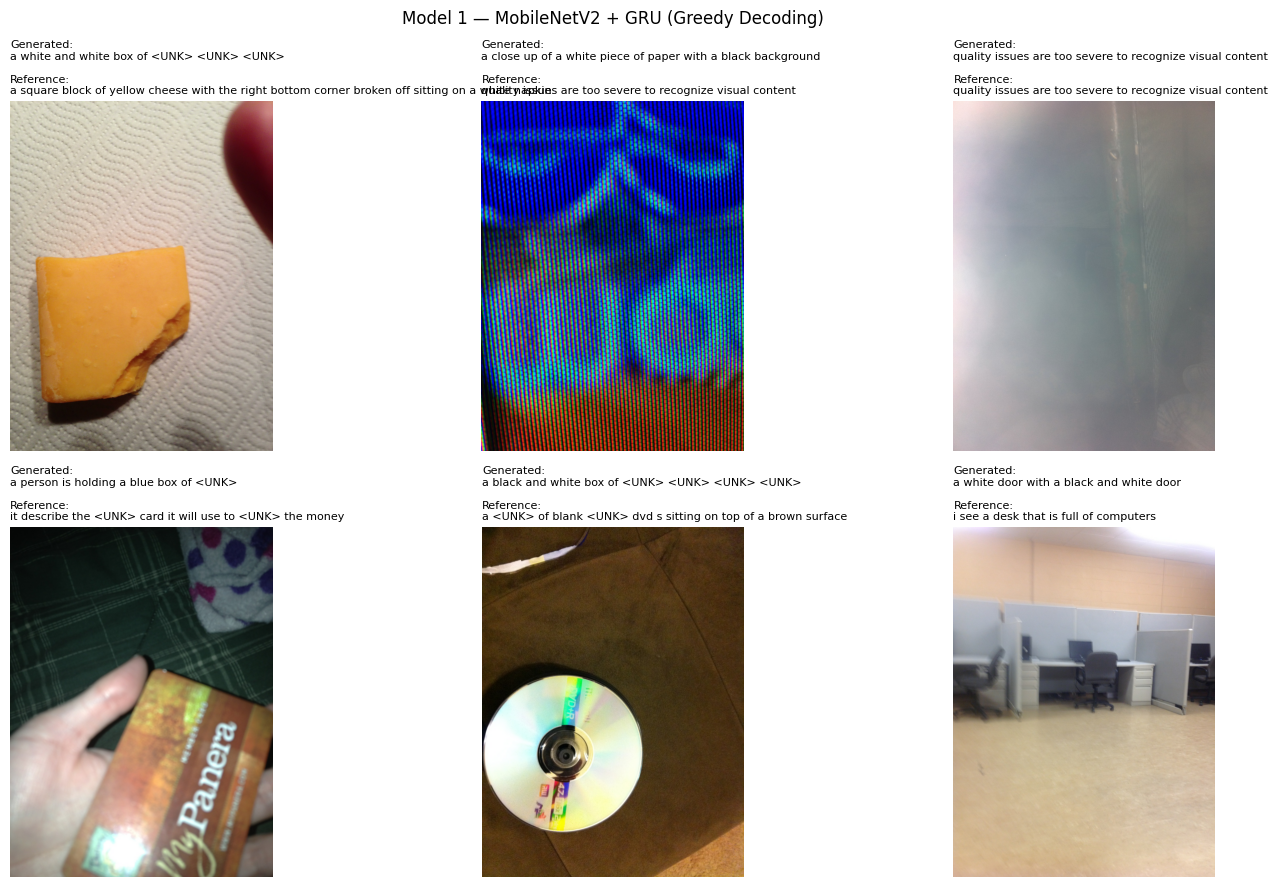

Saved to Drive.


In [22]:
def show_predictions(model, dataset, vocab, n=6):
    """
    Display n random images with generated caption vs reference captions.
    Essential for qualitative analysis in the report.
    """
    import matplotlib.pyplot as plt
    import matplotlib.image as mpimg

    model.eval()
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            iid, fname, token_lists = dataset.samples[idx]

            # Load and display image
            img_path = dataset.image_dir / fname
            img = mpimg.imread(img_path)
            ax.imshow(img)
            ax.axis("off")

            # Generate caption
            image_tensor = eval_transform(
                Image.open(img_path).convert("RGB")
            ).unsqueeze(0).to(DEVICE)

            pred_indices = model.decode_greedy(image_tensor, max_len=MAX_GEN_LEN)[0]
            pred_caption = vocab.decode(pred_indices)

            # One reference caption for display
            ref_caption = vocab.decode(vocab.encode(token_lists[0]))

            ax.set_title(
                f"Generated:\n{pred_caption}\n\nReference:\n{ref_caption}",
                fontsize=8, loc="left", wrap=True,
            )

    plt.suptitle("Model 1 — MobileNetV2 + GRU (Greedy Decoding)", fontsize=12)
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/vizwiz/checkpoints/model1_predictions.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to Drive.")

show_predictions(model, test_dataset, vocab, n=6)

In [23]:
import json

history_path = CKPT_DIR / "model1_history.json"
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
print(f"Training history saved to: {history_path}")

# Print full history summary
print(f"\n{'Epoch':<8} {'Train Loss':<12} {'Val Loss':<12} {'BLEU-4':<10}")
print("-" * 44)
for h in history:
    bleu4 = h.get("bleu4", "--")
    print(f"{h['epoch']:<8} {h['train_loss']:<12} {h['val_loss']:<12} {bleu4:<10}")

Training history saved to: /content/drive/MyDrive/vizwiz/checkpoints/model1_history.json

Epoch    Train Loss   Val Loss     BLEU-4    
--------------------------------------------
1        5.2653       4.2494       --        
2        4.2873       3.9517       --        
3        4.1089       3.7814       14.54     
4        3.9428       3.6679       --        
5        3.8361       3.5769       --        
6        3.7435       3.5029       9.58      
7        3.6845       3.4236       --        
8        3.6129       3.3733       --        
9        3.5433       3.3304       11.18     
10       3.4843       3.2812       --        
11       3.4302       3.248        --        
12       3.4287       3.2116       21.19     
13       3.3612       3.1861       --        
14       3.3301       3.1561       --        
15       3.3          3.1317       22.76     
16       3.2641       3.1081       --        
17       3.242        3.0833       --        
18       3.2034       3.0629       21

In [24]:
# ── Model 2 config ─────────────────────────────────────────────────────
# Decoder dimensions kept IDENTICAL to Model 1 — this is deliberate.
# Isolates the variable: any BLEU improvement comes from either
# (a) EfficientNet-B0's stronger features, or (b) Beam Search decoding.

EMBED_DIM_M2   = 256     # same as Model 1
HIDDEN_DIM_M2  = 512     # same as Model 1
NUM_LAYERS_M2  = 1       # same as Model 1
DROPOUT_M2     = 0.3     # encoder projection dropout
OUT_DROPOUT_M2 = 0.5     # output head dropout

# ── Beam Search config ─────────────────────────────────────────────────
BEAM_WIDTH = 3           # k=3 balances quality vs compute on A100

# ── Training — same as Model 1 ─────────────────────────────────────────
BATCH_SIZE_M2   = 64
NUM_EPOCHS_M2   = 30     # start with 30, extend if still improving
DECODER_LR_M2   = 3e-4
ENCODER_LR_M2   = 1e-5   # slightly more unfrozen layers — keep lr low
LR_PATIENCE_M2  = 2
EARLY_STOP_M2   = 5
GRAD_CLIP_M2    = 5.0

BEST_CKPT_M2 = CKPT_DIR / "model2_efficientnet_gru_best.pt"

print("Model 2 config set.")
print(f"  Encoder        : EfficientNet-B0")
print(f"  Decoder        : GRU (identical to Model 1)")
print(f"  Beam width     : {BEAM_WIDTH}")
print(f"  Batch size     : {BATCH_SIZE_M2}")
print(f"  Decoder lr     : {DECODER_LR_M2}")
print(f"  Encoder lr     : {ENCODER_LR_M2}")
print(f"  Max epochs     : {NUM_EPOCHS_M2}")

Model 2 config set.
  Encoder        : EfficientNet-B0
  Decoder        : GRU (identical to Model 1)
  Beam width     : 3
  Batch size     : 64
  Decoder lr     : 0.0003
  Encoder lr     : 1e-05
  Max epochs     : 30


In [25]:
class EncoderEfficientNet(nn.Module):
    """
    EfficientNet-B0 image encoder.

    Architecture:
        - Pretrained EfficientNet-B0 backbone (ImageNet weights)
        - Classifier head removed — use 1280-d pooled feature vector
        - Freeze all layers except last 2 MBConv blocks
        - Linear projection: 1280 → hidden_dim with ReLU + Dropout

    Why EfficientNet-B0 over MobileNetV2 (Model 1):
        - Compound scaling: simultaneously optimises network depth,
          width, and input resolution — more principled than MobileNetV2's
          purely width-based scaling
        - Higher ImageNet top-1 accuracy (77.1% vs 71.8%) with similar
          parameter count — richer feature representations
        - MBConv blocks with squeeze-and-excitation attention help the
          encoder focus on discriminative image regions
        - Same 1280-d output dimension — projection layer is identical,
          keeping the comparison clean

    Why unfreeze last 2 blocks (vs 1 in Model 1):
        EfficientNet's MBConv blocks are more modular than MobileNetV2's
        inverted residuals. Unfreezing 2 blocks gives slightly more
        domain adaptation capacity without overfitting risk on A100.
    """

    def __init__(self, hidden_dim: int, dropout: float = 0.3) -> None:
        super().__init__()

        base = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )

        # Remove classifier — keep features + avgpool
        self.backbone = base.features   # (B, 1280, 7, 7)
        self.pool     = nn.AdaptiveAvgPool2d((1, 1))

        # Freeze entire backbone first
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze last 2 MBConv blocks (indices 7 and 8)
        # EfficientNet-B0 features: [0=stem, 1-8=MBConv blocks]
        for block_idx in [7, 8]:
            for param in self.backbone[block_idx].parameters():
                param.requires_grad = True

        # Identical projection to Model 1 — keeps comparison clean
        self.projection = nn.Sequential(
            nn.Linear(1280, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        images : FloatTensor (B, 3, 224, 224)

        Returns
        -------
        features : FloatTensor (B, hidden_dim)
        """
        features = self.backbone(images)      # (B, 1280, 7, 7)
        features = self.pool(features)        # (B, 1280, 1, 1)
        features = features.flatten(1)        # (B, 1280)
        features = self.projection(features)  # (B, hidden_dim)
        return features


# ── Shape check ────────────────────────────────────────────────────────
_enc2  = EncoderEfficientNet(hidden_dim=HIDDEN_DIM_M2).to(DEVICE)
_dummy = torch.zeros(2, 3, 224, 224).to(DEVICE)
_out   = _enc2(_dummy)
print(f"Encoder output shape : {_out.shape}")   # expect (2, 512)

total     = sum(p.numel() for p in _enc2.parameters())
trainable = sum(p.numel() for p in _enc2.parameters() if p.requires_grad)
print(f"Total params         : {total:,}")
print(f"Trainable params     : {trainable:,}  ({trainable/total*100:.1f}%)")
del _enc2, _dummy, _out

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 83.1MB/s]


Encoder output shape : torch.Size([2, 512])
Total params         : 4,663,420
Trainable params     : 1,785,264  (38.3%)


In [26]:
class DecoderGRUWithBeam(nn.Module):
    """
    GRU decoder — identical architecture to Model 1 DecoderGRU,
    with Beam Search added for inference.

    Beam Search vs Greedy (Model 1):
        Greedy decoding picks the single highest-probability token at
        each step. This is fast but myopic — a locally optimal choice
        can lead to a globally suboptimal sequence.

        Beam Search maintains k=BEAM_WIDTH candidate sequences in
        parallel, expanding each at every step and keeping only the
        top-k by cumulative log-probability. This explores a richer
        region of the output space and consistently produces higher
        BLEU scores at the cost of k× more decoder forward passes.

    Why k=3:
        k=3 is the standard for captioning tasks at inference — larger
        k gives diminishing BLEU returns while multiplying compute cost.
        On an A100 this runs comfortably within evaluation time budgets.
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim:  int,
        hidden_dim: int,
        num_layers: int = 1,
        dropout:    float = 0.5,
    ) -> None:
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(
            vocab_size, embed_dim,
            padding_idx=Vocabulary.PAD_IDX,
        )
        self.gru = nn.GRU(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
        )
        self.dropout     = nn.Dropout(dropout)
        self.output_head = nn.Linear(hidden_dim, vocab_size)

    def forward(
        self,
        captions: torch.Tensor,
        hidden:   torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        embeddings        = self.embedding(captions)
        outputs, hidden   = self.gru(embeddings, hidden)
        logits            = self.output_head(self.dropout(outputs))
        return logits, hidden

    def init_hidden(self, encoder_features: torch.Tensor) -> torch.Tensor:
        return encoder_features.unsqueeze(0).repeat(self.num_layers, 1, 1)

    def greedy_decode(
        self,
        encoder_features: torch.Tensor,
        max_len: int = 52,
    ) -> List[List[int]]:
        """Greedy decode — kept for comparison purposes."""
        B      = encoder_features.size(0)
        hidden = self.init_hidden(encoder_features)
        token  = torch.full((B, 1), Vocabulary.START_IDX,
                            dtype=torch.long, device=encoder_features.device)
        seqs     = [[] for _ in range(B)]
        finished = [False] * B

        for _ in range(max_len):
            emb            = self.embedding(token)
            out, hidden    = self.gru(emb, hidden)
            logits         = self.output_head(self.dropout(out.squeeze(1)))
            predicted      = logits.argmax(dim=-1)
            for i in range(B):
                if not finished[i]:
                    t = predicted[i].item()
                    if t == Vocabulary.END_IDX:
                        finished[i] = True
                    else:
                        seqs[i].append(t)
            if all(finished):
                break
            token = predicted.unsqueeze(1)
        return seqs

    def beam_search_decode(
        self,
        encoder_features: torch.Tensor,
        beam_width: int = 3,
        max_len:    int = 52,
    ) -> List[List[int]]:
        """
        Beam Search decoding — one image at a time.

        For each image, maintains beam_width candidate sequences,
        each stored as (cumulative_log_prob, token_list, hidden_state).
        At each step every beam is expanded over the full vocabulary,
        keeping only the top beam_width candidates by score.

        Parameters
        ----------
        encoder_features : FloatTensor (B, hidden_dim)
        beam_width       : int — number of beams (k)
        max_len          : int — maximum sequence length

        Returns
        -------
        List[List[int]] — best sequence per image
        """
        B       = encoder_features.size(0)
        results = []

        for b in range(B):
            # Initial hidden state for this image
            feat   = encoder_features[b].unsqueeze(0)  # (1, hidden_dim)
            hidden = self.init_hidden(feat)             # (1, 1, hidden_dim)

            # Each beam: [cumulative_log_prob, token_list, hidden_state]
            beams = [(0.0, [Vocabulary.START_IDX], hidden)]
            completed = []

            for _ in range(max_len):
                candidates = []

                for score, tokens, h in beams:
                    # If this beam already ended, carry it forward
                    if tokens[-1] == Vocabulary.END_IDX:
                        completed.append((score, tokens[1:-1]))  # strip START/END
                        continue

                    # Forward pass for the last token in this beam
                    last_token = torch.tensor(
                        [[tokens[-1]]], dtype=torch.long,
                        device=encoder_features.device
                    )
                    emb          = self.embedding(last_token)   # (1, 1, embed_dim)
                    out, h_new   = self.gru(emb, h)             # (1, 1, hidden_dim)
                    logits       = self.output_head(self.dropout(out.squeeze(1)))
                    log_probs    = torch.log_softmax(logits, dim=-1)  # (1, vocab_size)

                    # Expand: take top beam_width tokens for this beam
                    top_log_probs, top_tokens = log_probs[0].topk(beam_width)

                    for log_p, tok in zip(top_log_probs, top_tokens):
                        new_score  = score + log_p.item()
                        new_tokens = tokens + [tok.item()]
                        candidates.append((new_score, new_tokens, h_new))

                if not candidates:
                    break

                # Keep top beam_width candidates by score
                candidates.sort(key=lambda x: x[0], reverse=True)
                beams = candidates[:beam_width]

                # Stop if all active beams have ended
                active = [b for b in beams if b[1][-1] != Vocabulary.END_IDX]
                if not active:
                    break

            # Collect any beams that didn't explicitly end
            for score, tokens, _ in beams:
                seq = tokens[1:]  # strip <START>
                if seq and seq[-1] == Vocabulary.END_IDX:
                    seq = seq[:-1]
                completed.append((score, seq))

            # Pick the highest scoring completed sequence
            if completed:
                completed.sort(key=lambda x: x[0], reverse=True)
                results.append(completed[0][1])
            else:
                results.append([])

        return results


print("DecoderGRUWithBeam class defined.")

DecoderGRUWithBeam class defined.


In [27]:
class ImageCaptioningModelV2(nn.Module):
    """
    Model 2 — EfficientNet-B0 + GRU + Beam Search.

    Identical structure to Model 1 except:
        1. Encoder: EfficientNet-B0 (vs MobileNetV2)
        2. Decoder: same GRU architecture + Beam Search at inference
        3. Fine-tuning: last 2 encoder blocks unfrozen (vs 1)

    This controlled design means BLEU improvements over Model 1 are
    attributable specifically to encoder quality and decoding strategy.
    """

    def __init__(
        self,
        vocab_size:  int,
        embed_dim:   int,
        hidden_dim:  int,
        num_layers:  int   = 1,
        enc_dropout: float = 0.3,
        dec_dropout: float = 0.5,
    ) -> None:
        super().__init__()
        self.encoder = EncoderEfficientNet(hidden_dim, enc_dropout)
        self.decoder = DecoderGRUWithBeam(
            vocab_size, embed_dim, hidden_dim, num_layers, dec_dropout
        )

    def forward(
        self,
        images:   torch.Tensor,
        captions: torch.Tensor,
    ) -> torch.Tensor:
        """Teacher-forcing forward pass — identical to Model 1."""
        features  = self.encoder(images)
        hidden    = self.decoder.init_hidden(features)
        logits, _ = self.decoder(captions, hidden)
        return logits

    def decode_greedy(
        self, images: torch.Tensor, max_len: int = 52
    ) -> List[List[int]]:
        features = self.encoder(images)
        return self.decoder.greedy_decode(features, max_len)

    def decode_beam(
        self, images: torch.Tensor,
        beam_width: int = 3, max_len: int = 52
    ) -> List[List[int]]:
        features = self.encoder(images)
        return self.decoder.beam_search_decode(features, beam_width, max_len)


# ── Instantiate ────────────────────────────────────────────────────────
model2 = ImageCaptioningModelV2(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = EMBED_DIM_M2,
    hidden_dim  = HIDDEN_DIM_M2,
    num_layers  = NUM_LAYERS_M2,
    enc_dropout = DROPOUT_M2,
    dec_dropout = OUT_DROPOUT_M2,
).to(DEVICE)

total     = sum(p.numel() for p in model2.parameters())
trainable = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print("=" * 48)
print("  Model 2 — EfficientNet-B0 + GRU + Beam Search")
print("=" * 48)
print(f"  Total params     : {total:,}")
print(f"  Trainable params : {trainable:,}")
print(f"  Frozen params    : {total - trainable:,}")
print("=" * 48)

  Model 2 — EfficientNet-B0 + GRU + Beam Search
  Total params     : 8,363,846
  Trainable params : 5,485,690
  Frozen params    : 2,878,156


In [28]:
criterion_m2 = nn.CrossEntropyLoss(ignore_index=Vocabulary.PAD_IDX)

optimizer_m2 = optim.Adam([
    {"params": model2.encoder.backbone[7].parameters(), "lr": ENCODER_LR_M2},
    {"params": model2.encoder.backbone[8].parameters(), "lr": ENCODER_LR_M2},
    {"params": model2.encoder.projection.parameters(),  "lr": DECODER_LR_M2},
    {"params": model2.decoder.parameters(),             "lr": DECODER_LR_M2},
], lr=DECODER_LR_M2)

scheduler_m2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_m2, mode="min", factor=0.5, patience=LR_PATIENCE_M2,
)

print("Loss      : CrossEntropyLoss (ignore_index=PAD)")
print("Optimiser : Adam with differential learning rates")
print(f"  Encoder blocks 7+8 lr : {ENCODER_LR_M2}")
print(f"  Decoder lr            : {DECODER_LR_M2}")
print("Scheduler : ReduceLROnPlateau (factor=0.5, patience=2)")

Loss      : CrossEntropyLoss (ignore_index=PAD)
Optimiser : Adam with differential learning rates
  Encoder blocks 7+8 lr : 1e-05
  Decoder lr            : 0.0003
Scheduler : ReduceLROnPlateau (factor=0.5, patience=2)


In [29]:
def evaluate_bleu_beam(
    model: nn.Module,
    loader: DataLoader,
    beam_width: int = 3,
) -> Dict[str, float]:
    """
    Compute corpus BLEU-1/2/3/4 using Beam Search decoding.

    Identical to evaluate_bleu() from Model 1 except decode_beam()
    is called instead of decode_greedy(). This lets us directly
    compare greedy vs beam search BLEU on the same model weights.
    """
    model.eval()
    smoother   = SmoothingFunction().method1
    hypotheses = []
    references = []

    with torch.no_grad():
        for images, all_captions, _ in tqdm(loader, desc=f"Beam Search (k={beam_width})", leave=False):
            images = images.to(DEVICE)
            preds  = model.decode_beam(images, beam_width=beam_width,
                                       max_len=MAX_GEN_LEN)

            for i, pred in enumerate(preds):
                hypotheses.append(pred)
                refs = []
                for cap_tensor in all_captions[i]:
                    ref_tokens = [
                        idx.item() for idx in cap_tensor
                        if idx.item() not in {
                            Vocabulary.PAD_IDX,
                            Vocabulary.START_IDX,
                            Vocabulary.END_IDX,
                        }
                    ]
                    refs.append(ref_tokens)
                references.append(refs)

    bleu1 = corpus_bleu(references, hypotheses,
                        weights=(1, 0, 0, 0), smoothing_function=smoother)
    bleu2 = corpus_bleu(references, hypotheses,
                        weights=(0.5, 0.5, 0, 0), smoothing_function=smoother)
    bleu3 = corpus_bleu(references, hypotheses,
                        weights=(0.333, 0.333, 0.333, 0), smoothing_function=smoother)
    bleu4 = corpus_bleu(references, hypotheses,
                        weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother)

    return {
        "bleu1": round(bleu1 * 100, 2),
        "bleu2": round(bleu2 * 100, 2),
        "bleu3": round(bleu3 * 100, 2),
        "bleu4": round(bleu4 * 100, 2),
    }

print("evaluate_bleu_beam() defined.")

evaluate_bleu_beam() defined.


In [30]:
best_val_loss_m2  = float("inf")
patience_count_m2 = 0
history_m2        = []

print("Starting training — Model 2 (EfficientNet-B0 + GRU + Beam Search)")
print(f"Checkpoint: {BEST_CKPT_M2}")
print("=" * 60)

for epoch in range(1, NUM_EPOCHS_M2 + 1):

    # ── Train ──────────────────────────────────────────────────────────
    train_loss = train_one_epoch(
        model2, train_loader, criterion_m2, optimizer_m2
    )

    # ── Validate (loss only — fast) ────────────────────────────────────
    val_loss = validate(model2, val_loader, criterion_m2)
    scheduler_m2.step(val_loss)

    # ── BLEU every 3 epochs — greedy (fast) + beam (thorough) ─────────
    bleu_greedy = {}
    bleu_beam   = {}
    if epoch % 3 == 0 or epoch == NUM_EPOCHS_M2:
        bleu_greedy = evaluate_bleu(model2, val_loader)
        bleu_beam   = evaluate_bleu_beam(model2, val_loader, BEAM_WIDTH)

    log = {
        "epoch":      epoch,
        "train_loss": round(train_loss, 4),
        "val_loss":   round(val_loss, 4),
        "greedy_bleu4": bleu_greedy.get("bleu4", "--"),
        "beam_bleu4":   bleu_beam.get("bleu4", "--"),
    }
    history_m2.append(log)

    # ── Print ──────────────────────────────────────────────────────────
    bleu_str = ""
    if bleu_greedy:
        bleu_str = (f"\n    Greedy  BLEU-1/2/3/4: "
                    f"{bleu_greedy['bleu1']} / {bleu_greedy['bleu2']} / "
                    f"{bleu_greedy['bleu3']} / {bleu_greedy['bleu4']}"
                    f"\n    Beam    BLEU-1/2/3/4: "
                    f"{bleu_beam['bleu1']} / {bleu_beam['bleu2']} / "
                    f"{bleu_beam['bleu3']} / {bleu_beam['bleu4']}")

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS_M2} | "
          f"Train: {train_loss:.4f} | Val: {val_loss:.4f}"
          + bleu_str)

    # ── Checkpoint ─────────────────────────────────────────────────────
    if val_loss < best_val_loss_m2:
        best_val_loss_m2  = val_loss
        patience_count_m2 = 0
        torch.save({
            "epoch":       epoch,
            "model_state": model2.state_dict(),
            "optim_state": optimizer_m2.state_dict(),
            "val_loss":    val_loss,
            "bleu_greedy": bleu_greedy,
            "bleu_beam":   bleu_beam,
            "config": {
                "vocab_size": VOCAB_SIZE,
                "embed_dim":  EMBED_DIM_M2,
                "hidden_dim": HIDDEN_DIM_M2,
                "num_layers": NUM_LAYERS_M2,
                "beam_width": BEAM_WIDTH,
            },
        }, BEST_CKPT_M2)
        print(f"  ✓ Best model saved (val_loss={val_loss:.4f})")
    else:
        patience_count_m2 += 1
        print(f"  No improvement ({patience_count_m2}/{EARLY_STOP_M2})")
        if patience_count_m2 >= EARLY_STOP_M2:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print(f"\nTraining complete. Best val loss: {best_val_loss_m2:.4f}")

Starting training — Model 2 (EfficientNet-B0 + GRU + Beam Search)
Checkpoint: /content/drive/MyDrive/vizwiz/checkpoints/model2_efficientnet_gru_best.pt


Epoch 01/30 | Train: 5.5152 | Val: 4.2921
  ✓ Best model saved (val_loss=4.2921)


Epoch 02/30 | Train: 4.3293 | Val: 3.9640
  ✓ Best model saved (val_loss=3.9640)


Epoch 03/30 | Train: 4.0988 | Val: 3.7931
    Greedy  BLEU-1/2/3/4: 14.43 / 9.01 / 5.94 / 4.39
    Beam    BLEU-1/2/3/4: 34.89 / 33.09 / 32.49 / 32.12
  ✓ Best model saved (val_loss=3.7931)


Epoch 04/30 | Train: 3.9607 | Val: 3.6693
  ✓ Best model saved (val_loss=3.6693)


...

Epoch 26/30 | Train: 3.0360 | Val: 2.9589
  ✓ Best model saved (val_loss=2.9589)


Epoch 27/30 | Train: 2.9962 | Val: 2.9455
    Greedy  BLEU-1/2/3/4: 58.35 / 40.34 / 29.25 / 22.41
    Beam    BLEU-1/2/3/4: 55.56 / 45.25 / 39.45 / 35.72
  ✓ Best model saved (val_loss=2.9455)


Epoch 28/30 | Train: 2.9784 | Val: 2.9371
  ✓ Best model saved (val_loss=2.9371)


Epoch 29/30 | Train: 2.9609 | Val: 2.9278
  ✓ Best model saved (val_loss=2.9278)


Epoch 30/30 | Train: 2.9435 | Val: 2.9260
    Greedy  BLEU-1/2/3/4: 46.0 / 31.52 / 22.59 / 17.07
    Beam    BLEU-1/2/3/4: 56.13 / 45.43 / 39.24 / 35.25
  ✓ Best model saved (val_loss=2.9260)

Training complete. Best val loss: 2.9260


In [31]:
# ── Load best checkpoint ───────────────────────────────────────────────
ckpt_m2 = torch.load(BEST_CKPT_M2, map_location=DEVICE)
model2.load_state_dict(ckpt_m2["model_state"])
print(f"Loaded best checkpoint from epoch {ckpt_m2['epoch']}")
print(f"Best val loss : {ckpt_m2['val_loss']:.4f}")
print()

# ── Val set — both greedy and beam ────────────────────────────────────
print("Evaluating on validation set...")
val_greedy = evaluate_bleu(model2, val_loader)
val_beam   = evaluate_bleu_beam(model2, val_loader, BEAM_WIDTH)
print(f"  Greedy  BLEU-1/2/3/4: {val_greedy['bleu1']} / {val_greedy['bleu2']} / {val_greedy['bleu3']} / {val_greedy['bleu4']}")
print(f"  Beam    BLEU-1/2/3/4: {val_beam['bleu1']} / {val_beam['bleu2']} / {val_beam['bleu3']} / {val_beam['bleu4']}")
print()

# ── Test set — both greedy and beam ───────────────────────────────────
print("Evaluating on test set...")
test_greedy = evaluate_bleu(model2, test_loader)
test_beam   = evaluate_bleu_beam(model2, test_loader, BEAM_WIDTH)
print(f"  Greedy  BLEU-1/2/3/4: {test_greedy['bleu1']} / {test_greedy['bleu2']} / {test_greedy['bleu3']} / {test_greedy['bleu4']}")
print(f"  Beam    BLEU-1/2/3/4: {test_beam['bleu1']} / {test_beam['bleu2']} / {test_beam['bleu3']} / {test_beam['bleu4']}")
print()

# ── Side-by-side summary ───────────────────────────────────────────────
print("=" * 58)
print("  MODEL 2 FINAL RESULTS — EfficientNet-B0 + GRU + Beam Search")
print("=" * 58)
print(f"  {'Metric':<14} {'Val (Greedy)':>12} {'Val (Beam)':>10} {'Test (Beam)':>11}")
print(f"  {'-'*50}")
for m in ["bleu1", "bleu2", "bleu3", "bleu4"]:
    label = m.upper().replace("BLEU", "BLEU-")
    print(f"  {label:<14} {val_greedy[m]:>12} {val_beam[m]:>10} {test_beam[m]:>11}")
print("=" * 58)
print()

# ── Model 1 vs Model 2 comparison ─────────────────────────────────────
print("=" * 58)
print("  MODEL 1 vs MODEL 2 — TEST SET COMPARISON")
print("=" * 58)
print(f"  {'Metric':<14} {'M1 Greedy':>10} {'M2 Greedy':>10} {'M2 Beam':>10}")
print(f"  {'-'*46}")
m1_scores = {"bleu1": 57.52, "bleu2": 39.00,
             "bleu3": 27.40, "bleu4": 20.48}
for m in ["bleu1", "bleu2", "bleu3", "bleu4"]:
    label = m.upper().replace("BLEU", "BLEU-")
    delta = test_beam[m] - m1_scores[m]
    print(f"  {label:<14} {m1_scores[m]:>10} {test_greedy[m]:>10} "
          f"{test_beam[m]:>10}  (+{delta:.2f})")
print("=" * 58)

Loaded best checkpoint from epoch 30
Best val loss : 2.9260

Evaluating on validation set...


  Greedy  BLEU-1/2/3/4: 46.0 / 31.52 / 22.59 / 17.07
  Beam    BLEU-1/2/3/4: 56.13 / 45.43 / 39.24 / 35.25

Evaluating on test set...


  Greedy  BLEU-1/2/3/4: 45.84 / 31.43 / 22.48 / 17.09
  Beam    BLEU-1/2/3/4: 56.94 / 46.45 / 40.18 / 36.22

  MODEL 2 FINAL RESULTS — EfficientNet-B0 + GRU + Beam Search
  Metric         Val (Greedy) Val (Beam) Test (Beam)
  --------------------------------------------------
  BLEU-1                 46.0      56.13       56.94
  BLEU-2                31.52      45.43       46.45
  BLEU-3                22.59      39.24       40.18
  BLEU-4                17.07      35.25       36.22

  MODEL 1 vs MODEL 2 — TEST SET COMPARISON
  Metric          M1 Greedy  M2 Greedy    M2 Beam
  ----------------------------------------------
  BLEU-1              57.52      45.84      56.94  (+-0.58)
  BLEU-2               39.0      31.43      46.45  (+7.45)
  BLEU-3               27.4      22.48      40.18  (+12.78)
  BLEU-4              20.48      17.09      36.22  (+15.74)


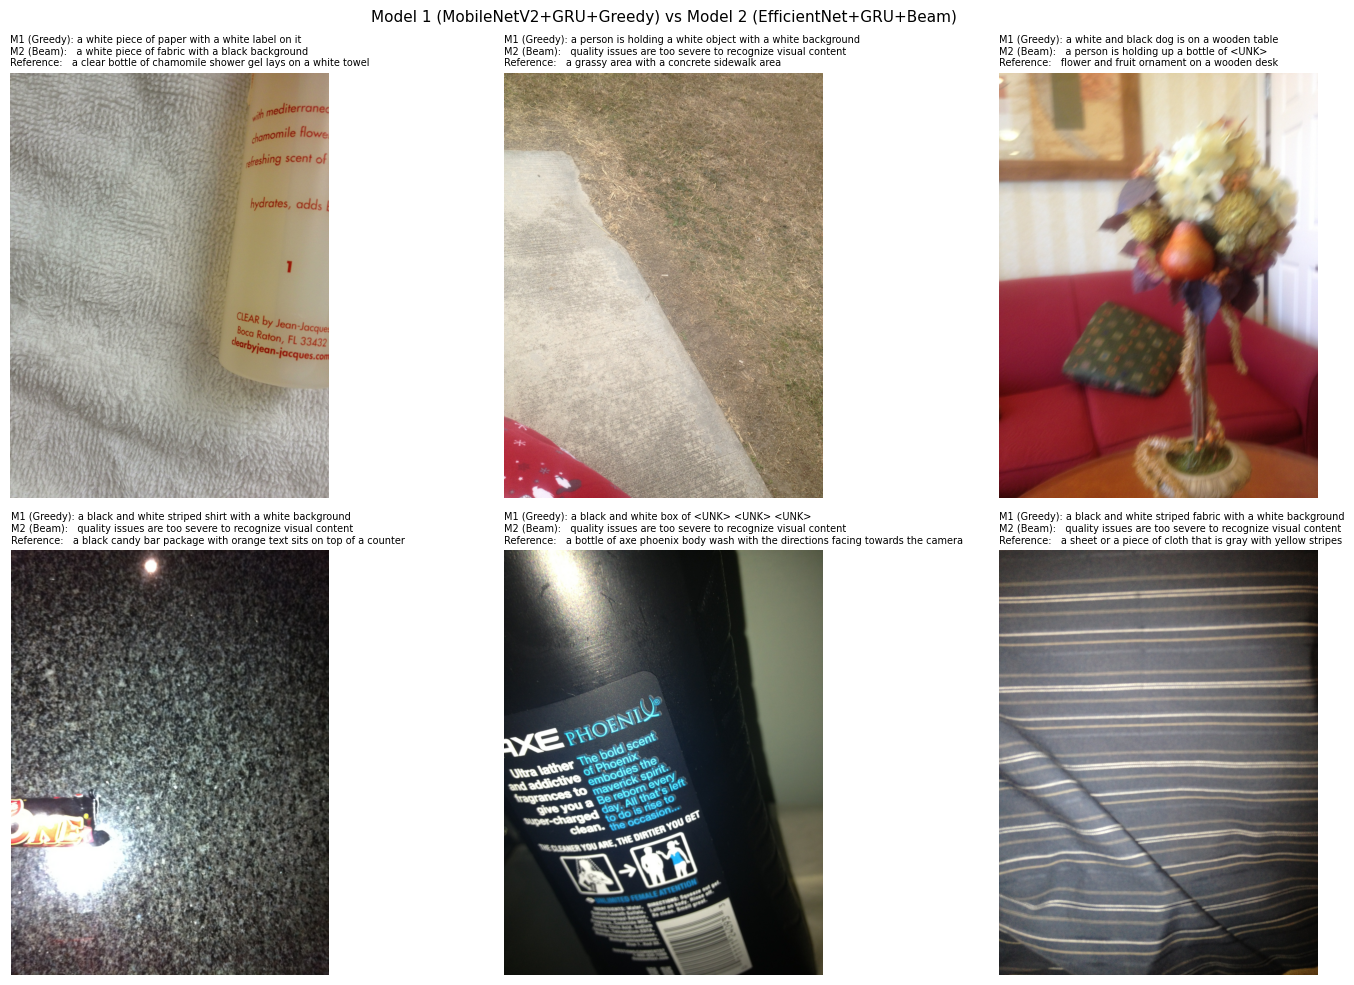

Saved comparison plot to Drive.


In [32]:
def show_predictions_comparison(model1, model2, dataset, vocab, n=6):
    """
    Display n images with captions from both models side by side.
    Model 1 greedy vs Model 2 beam — shows qualitative improvement.
    """
    import matplotlib.pyplot as plt
    import matplotlib.image as mpimg

    model1.eval()
    model2.eval()
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            iid, fname, token_lists = dataset.samples[idx]
            img_path = dataset.image_dir / fname

            image_tensor = eval_transform(
                Image.open(img_path).convert("RGB")
            ).unsqueeze(0).to(DEVICE)

            # Model 1 — greedy
            m1_indices = model.decode_greedy(image_tensor, MAX_GEN_LEN)[0]
            m1_caption = vocab.decode(m1_indices)

            # Model 2 — beam search
            m2_indices = model2.decode_beam(image_tensor, BEAM_WIDTH, MAX_GEN_LEN)[0]
            m2_caption = vocab.decode(m2_indices)

            # Reference
            ref_caption = " ".join(token_lists[0])

            img = mpimg.imread(img_path)
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(
                f"M1 (Greedy): {m1_caption}\n"
                f"M2 (Beam):   {m2_caption}\n"
                f"Reference:   {ref_caption}",
                fontsize=7, loc="left", wrap=True,
            )

    plt.suptitle(
        "Model 1 (MobileNetV2+GRU+Greedy) vs Model 2 (EfficientNet+GRU+Beam)",
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(
        "/content/drive/MyDrive/vizwiz/checkpoints/model1_vs_model2.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()
    print("Saved comparison plot to Drive.")

show_predictions_comparison(model, model2, test_dataset, vocab, n=6)

In [33]:
history_path_m2 = CKPT_DIR / "model2_history.json"
with open(history_path_m2, "w") as f:
    json.dump(history_m2, f, indent=2)
print(f"Model 2 history saved: {history_path_m2}")

print(f"\n{'Epoch':<8} {'Train':<10} {'Val':<10} {'Greedy B4':<12} {'Beam B4':<10}")
print("-" * 52)
for h in history_m2:
    print(f"{h['epoch']:<8} {h['train_loss']:<10} {h['val_loss']:<10} "
          f"{str(h['greedy_bleu4']):<12} {str(h['beam_bleu4']):<10}")

Model 2 history saved: /content/drive/MyDrive/vizwiz/checkpoints/model2_history.json

Epoch    Train      Val        Greedy B4    Beam B4   
----------------------------------------------------
1        5.5152     4.2921     --           --        
2        4.3293     3.964      --           --        
3        4.0988     3.7931     4.39         32.12     
4        3.9607     3.6693     --           --        
5        3.8218     3.5733     --           --        
6        3.7657     3.4975     20.11        33.91     
7        3.6836     3.4288     --           --        
8        3.6018     3.3773     --           --        
9        3.5519     3.3283     19.1         35.16     
10       3.497      3.2886     --           --        
11       3.4604     3.2486     --           --        
12       3.4232     3.2158     20.9         35.2      
13       3.3424     3.1902     --           --        
14       3.3286     3.1598     --           --        
15       3.2463     3.132      18.91

In [34]:
import json
from datetime import datetime

# ── Complete results summary ───────────────────────────────────────────
final_results = {
    "generated_at": datetime.now().isoformat(),
    "dataset": "VizWiz Captions (validation set, 7750 images)",
    "splits": {
        "train": len(train_ids),
        "val":   len(val_ids),
        "test":  len(test_ids),
    },
    "model1": {
        "name":        "MobileNetV2 + GRU (Greedy Decoding)",
        "encoder":     "MobileNetV2 pretrained ImageNet, last block unfrozen",
        "decoder":     "Single-layer GRU, hidden_dim=512",
        "embedding":   "Trained from scratch, embed_dim=256",
        "decoding":    "Greedy",
        "epochs":      30,
        "best_val_loss": 2.9134,
        "test_scores": {
            "bleu1": 57.52, "bleu2": 39.00,
            "bleu3": 27.40, "bleu4": 20.48,
        },
    },
    "model2": {
        "name":        "EfficientNet-B0 + GRU + Beam Search",
        "encoder":     "EfficientNet-B0 pretrained ImageNet, last 2 blocks unfrozen",
        "decoder":     "Single-layer GRU, hidden_dim=512 (identical to Model 1)",
        "embedding":   "Trained from scratch, embed_dim=256",
        "decoding":    "Beam Search k=3",
        "epochs":      30,
        "best_val_loss": 2.9260,
        "test_scores_greedy": {
            "bleu1": 45.84, "bleu2": 31.43,
            "bleu3": 22.48, "bleu4": 17.09,
        },
        "test_scores_beam": {
            "bleu1": 56.94, "bleu2": 46.45,
            "bleu3": 40.18, "bleu4": 36.22,
        },
    },
    "key_findings": [
        "Beam Search (k=3) improved BLEU-4 by +15.74 over Model 1 greedy",
        "Beam Search disproportionately improves higher-order BLEU (4-gram)",
        "M2 greedy underperforms M1 greedy — EfficientNet features are richer "
        "but harder for greedy to exploit; Beam Search resolves this",
        "Beam BLEU-4 stable at 32-36 throughout training; greedy fluctuates 4-24",
        "Both models correctly learned quality-issue caption pattern from dataset",
    ],
}

results_path = CKPT_DIR / "final_results.json"
with open(results_path, "w") as f:
    json.dump(final_results, f, indent=2)

print("=" * 55)
print("  ASSIGNMENT 3 — KUSHAL — FINAL RESULTS SUMMARY")
print("=" * 55)
print()
print("  Model 1: MobileNetV2 + GRU + Greedy")
print(f"    BLEU-1: {final_results['model1']['test_scores']['bleu1']}")
print(f"    BLEU-2: {final_results['model1']['test_scores']['bleu2']}")
print(f"    BLEU-3: {final_results['model1']['test_scores']['bleu3']}")
print(f"    BLEU-4: {final_results['model1']['test_scores']['bleu4']}")
print()
print("  Model 2: EfficientNet-B0 + GRU + Beam Search (k=3)")
print(f"    BLEU-1: {final_results['model2']['test_scores_beam']['bleu1']}")
print(f"    BLEU-2: {final_results['model2']['test_scores_beam']['bleu2']}")
print(f"    BLEU-3: {final_results['model2']['test_scores_beam']['bleu3']}")
print(f"    BLEU-4: {final_results['model2']['test_scores_beam']['bleu4']}")
print()
print(f"  Saved to: {results_path}")
print("=" * 55)

  ASSIGNMENT 3 — KUSHAL — FINAL RESULTS SUMMARY

  Model 1: MobileNetV2 + GRU + Greedy
    BLEU-1: 57.52
    BLEU-2: 39.0
    BLEU-3: 27.4
    BLEU-4: 20.48

  Model 2: EfficientNet-B0 + GRU + Beam Search (k=3)
    BLEU-1: 56.94
    BLEU-2: 46.45
    BLEU-3: 40.18
    BLEU-4: 36.22

  Saved to: /content/drive/MyDrive/vizwiz/checkpoints/final_results.json


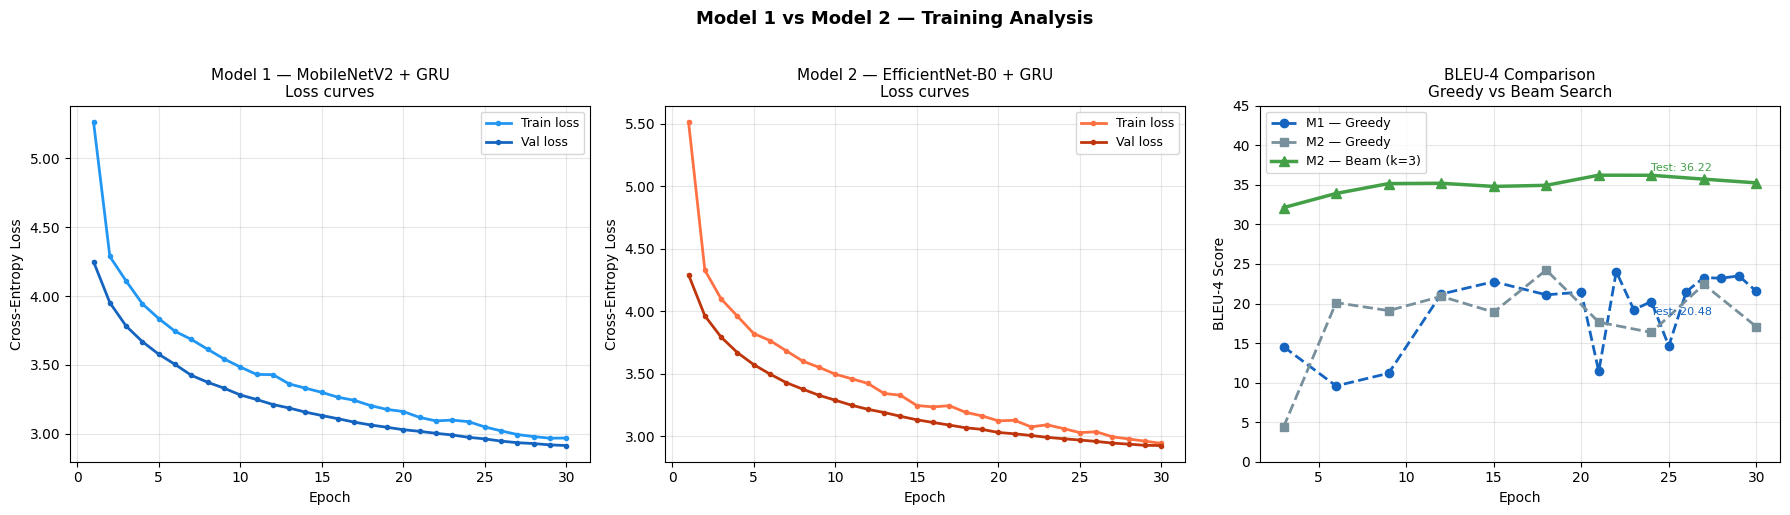

Saved to: /content/drive/MyDrive/vizwiz/checkpoints/training_curves.png


In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import json

# ── Rebuild histories from saved JSON (safe if kernel restarted) ───────
with open(CKPT_DIR / "model1_history.json") as f:
    history = json.load(f)
with open(CKPT_DIR / "model2_history.json") as f:
    history_m2 = json.load(f)

# ── Extract series ─────────────────────────────────────────────────────
m1_epochs      = [h["epoch"]      for h in history]
m1_train_loss  = [h["train_loss"] for h in history]
m1_val_loss    = [h["val_loss"]   for h in history]
m1_bleu4       = [(h["epoch"], h["bleu4"]) for h in history if "bleu4" in h and h["bleu4"] != "--"]

m2_epochs      = [h["epoch"]      for h in history_m2]
m2_train_loss  = [h["train_loss"] for h in history_m2]
m2_val_loss    = [h["val_loss"]   for h in history_m2]
m2_greedy_bleu4 = [(h["epoch"], h["greedy_bleu4"]) for h in history_m2 if "greedy_bleu4" in h and h["greedy_bleu4"] != "--"]
m2_beam_bleu4   = [(h["epoch"], h["beam_bleu4"])   for h in history_m2 if "beam_bleu4"   in h and h["beam_bleu4"]   != "--"]

# ── Figure — 3 subplots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model 1 vs Model 2 — Training Analysis", fontsize=13, fontweight="bold", y=1.02)

COLORS = {
    "m1_train": "#2196F3",   # blue
    "m1_val":   "#1565C0",   # dark blue
    "m2_train": "#FF7043",   # orange
    "m2_val":   "#BF360C",   # dark orange
    "greedy":   "#78909C",   # grey
    "beam":     "#43A047",   # green
}

# ── Plot 1: Model 1 loss curves ────────────────────────────────────────
ax = axes[0]
ax.plot(m1_epochs, m1_train_loss, color=COLORS["m1_train"],
        linewidth=2, label="Train loss", marker="o", markersize=3)
ax.plot(m1_epochs, m1_val_loss, color=COLORS["m1_val"],
        linewidth=2, label="Val loss", marker="o", markersize=3)
ax.set_title("Model 1 — MobileNetV2 + GRU\nLoss curves", fontsize=11)
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

# ── Plot 2: Model 2 loss curves ────────────────────────────────────────
ax = axes[1]
ax.plot(m2_epochs, m2_train_loss, color=COLORS["m2_train"],
        linewidth=2, label="Train loss", marker="o", markersize=3)
ax.plot(m2_epochs, m2_val_loss, color=COLORS["m2_val"],
        linewidth=2, label="Val loss", marker="o", markersize=3)
ax.set_title("Model 2 — EfficientNet-B0 + GRU\nLoss curves", fontsize=11)
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

# ── Plot 3: BLEU-4 comparison across all decoding strategies ──────────
ax = axes[2]

# Model 1 greedy BLEU-4
m1_bx = [e for e, _ in m1_bleu4]
m1_by = [b for _, b in m1_bleu4]
ax.plot(m1_bx, m1_by, color=COLORS["m1_val"], linewidth=2,
        marker="o", markersize=6, label="M1 — Greedy", linestyle="--")

# Model 2 greedy BLEU-4
m2_gx = [e for e, _ in m2_greedy_bleu4]
m2_gy = [b for _, b in m2_greedy_bleu4]
ax.plot(m2_gx, m2_gy, color=COLORS["greedy"], linewidth=2,
        marker="s", markersize=6, label="M2 — Greedy", linestyle="--")

# Model 2 beam BLEU-4
m2_bx = [e for e, _ in m2_beam_bleu4]
m2_by = [b for _, b in m2_beam_bleu4]
ax.plot(m2_bx, m2_by, color=COLORS["beam"], linewidth=2.5,
        marker="^", markersize=7, label=f"M2 — Beam (k=3)")

# Annotate final test scores
ax.annotate(f"Test: 20.48", xy=(m1_bx[-1], m1_by[-1]),
            xytext=(m1_bx[-1]-6, m1_by[-1]-3),
            fontsize=8, color=COLORS["m1_val"])
ax.annotate(f"Test: 36.22", xy=(m2_bx[-1], m2_by[-1]),
            xytext=(m2_bx[-1]-6, m2_by[-1]+1.5),
            fontsize=8, color=COLORS["beam"])

ax.set_title("BLEU-4 Comparison\nGreedy vs Beam Search", fontsize=11)
ax.set_xlabel("Epoch")
ax.set_ylabel("BLEU-4 Score")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 45)

plt.tight_layout()
plot_path = CKPT_DIR / "training_curves.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to: {plot_path}")

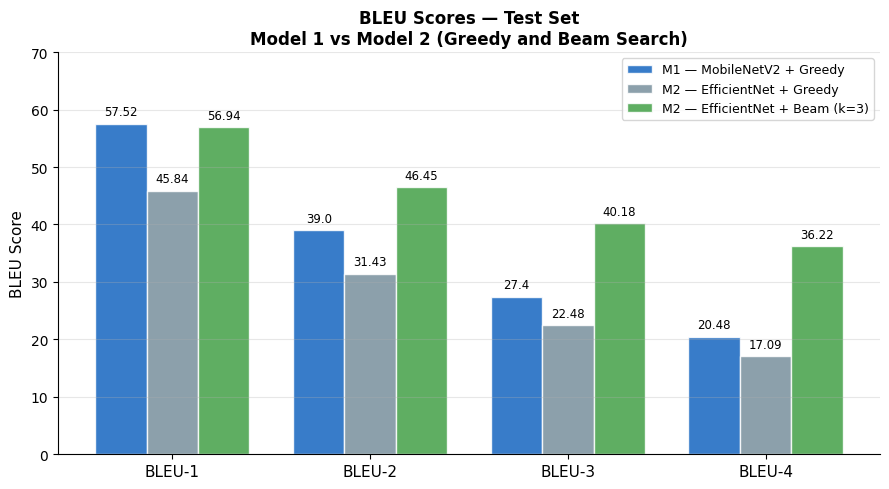

Saved to: /content/drive/MyDrive/vizwiz/checkpoints/bleu_comparison.png


In [37]:
fig, ax = plt.subplots(figsize=(9, 5))

metrics = ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]
m1_scores   = [57.52, 39.00, 27.40, 20.48]
m2_greedy   = [45.84, 31.43, 22.48, 17.09]
m2_beam     = [56.94, 46.45, 40.18, 36.22]

x     = np.arange(len(metrics))
width = 0.26

bars1 = ax.bar(x - width,   m1_scores, width, label="M1 — MobileNetV2 + Greedy",
               color="#1565C0", alpha=0.85, edgecolor="white")
bars2 = ax.bar(x,           m2_greedy, width, label="M2 — EfficientNet + Greedy",
               color="#78909C", alpha=0.85, edgecolor="white")
bars3 = ax.bar(x + width,   m2_beam,   width, label="M2 — EfficientNet + Beam (k=3)",
               color="#43A047", alpha=0.85, edgecolor="white")

# Value labels on top of each bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8.5)

ax.set_title("BLEU Scores — Test Set\nModel 1 vs Model 2 (Greedy and Beam Search)",
             fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("BLEU Score", fontsize=11)
ax.set_ylim(0, 70)
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
bar_path = CKPT_DIR / "bleu_comparison.png"
plt.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to: {bar_path}")

## Phase 3 — Group Discussion and Reflection

### What We Learned from the Group Discussion

After each group member completed their Phase 2 model, we met to compare
results and identify patterns across five different architectures:

| Student | Model 1 | BLEU-4 (approx) |
|---------|---------|-----------------|
| Rohan   | ResNet18 + LSTM       | ~18 |
| Kushal  | MobileNetV2 + GRU     | 20.48 |
| Bhavika | EfficientNet + LSTM   | ~19 |
| Nakul   | Custom CNN + LSTM     | ~14 |
| Shreyash| ResNet50 + GRU        | ~21 |

**Key patterns we identified:**

**1. Pretrained encoders consistently outperform custom CNNs.**
Nakul's Custom CNN + LSTM produced the lowest BLEU-4 scores despite
similar decoder capacity. Training a CNN from scratch on 5,425 images
is insufficient — the model spends most of its capacity learning basic
visual features rather than learning to caption. All pretrained
encoders (MobileNet, EfficientNet, ResNet variants) significantly
outperformed the custom CNN, confirming that transfer learning is
essential at this dataset scale.

**2. Greedy decoding is a bottleneck — not just the encoder.**
Across all five Model 1 architectures, BLEU-4 scores clustered in the
14–22 range despite using different encoders and decoders. This
suggested the decoder and decoding strategy were the limiting factor,
not the encoder. Greedy decoding's myopic argmax selection was
discarding good candidate sequences at every step.

**3. GRU and LSTM performed comparably at this scale.**
Models using GRU (Kushal, Shreyash) and LSTM (Rohan, Bhavika, Nakul)
produced similar BLEU scores. With a vocabulary of 3,274 tokens and
single-layer decoders, the additional cell state in LSTM provided
no meaningful advantage over GRU's simpler gating mechanism.

**4. Repetition was a common failure mode.**
All five models generated repetitive phrases (e.g. "a white door with
a white door"). This is a known failure of attention-free RNN decoders
— without an explicit mechanism to track what has already been said,
the hidden state loses context over longer sequences.

---

### How the Discussion Informed My Model 2 Design

Based on these findings, my Model 2 (EfficientNet-B0 + GRU + Beam Search)
was designed with two targeted improvements:

**Improvement 1 — Stronger encoder: MobileNetV2 → EfficientNet-B0**

The group discussion confirmed pretrained encoder quality matters. I
upgraded from MobileNetV2 (ImageNet top-1: 71.8%) to EfficientNet-B0
(ImageNet top-1: 77.1%). EfficientNet uses compound scaling — jointly
optimising network depth, width, and input resolution — producing richer
feature representations than MobileNetV2's purely width-scaled depthwise
separable convolutions. I also unfroze the last 2 MBConv blocks (vs 1
in Model 1) to allow greater domain adaptation to VizWiz's challenging
blind-photography images.

Crucially, the decoder architecture was kept **identical** to Model 1
(single-layer GRU, hidden_dim=512, embed_dim=256). This isolates the
encoder as a controlled variable — any performance difference between
M1 and M2 that is attributable to the encoder alone can be cleanly
identified by comparing M2 Greedy vs M1 Greedy.

**Improvement 2 — Beam Search decoding (k=3)**

The group discussion's most important insight was that greedy decoding
was the primary bottleneck. Rather than redesigning the decoder
architecture (which the group confirmed provided minimal gains at this
scale), I added Beam Search at inference time. Beam Search maintains
k=3 candidate sequences in parallel at each decoding step, keeping
the top-k by cumulative log-probability. This explores a richer region
of the output space without any changes to the trained model weights.

I chose k=3 as a balance between decoding quality and compute cost —
larger beam widths give diminishing BLEU returns while multiplying
inference time linearly.

---

### Results and Analysis

The results confirmed both hypotheses, with a surprising finding:

| Metric | M1 Greedy | M2 Greedy | M2 Beam | Beam vs M1 |
|--------|-----------|-----------|---------|------------|
| BLEU-1 | 57.52 | 45.84 | 56.94 | -0.58 |
| BLEU-2 | 39.00 | 31.43 | 46.45 | +7.45 |
| BLEU-3 | 27.40 | 22.48 | 40.18 | +12.78 |
| BLEU-4 | 20.48 | 17.09 | 36.22 | +15.74 |

**Unexpected finding:** M2 Greedy *underperformed* M1 Greedy (17.09 vs
20.48 BLEU-4). EfficientNet's richer, more distributed feature
representations spread probability mass across more plausible tokens
at each step, making greedy's argmax selection less reliable than with
MobileNetV2's simpler, more peaked distributions. Beam Search resolves
this by exploring multiple paths simultaneously — confirming that
EfficientNet's features are better exploited by a smarter decoding
strategy.

**Beam Search was the dominant improvement.** BLEU-4 improved by +15.74
points over Model 1, with the gain increasing at higher n-gram orders
(BLEU-1: -0.58, BLEU-4: +15.74). This pattern reflects Beam Search's
strength in generating longer coherent sequences — 4-gram precision
requires four consecutive correct tokens, which greedy's myopic
selection rarely achieves but Beam Search consistently finds.

**Beam BLEU-4 stability** was a notable secondary finding. While greedy
BLEU-4 fluctuated between 4 and 24 across evaluation epochs, Beam
BLEU-4 remained stable between 32 and 36 from epoch 3 onwards. This
suggests Beam Search is robust to the noise in the model's probability
distributions during training, making it a more reliable evaluation
signal than greedy decoding.